In [3]:
from scipy.stats import norm
import numpy as np
import time
#from Geometric_Brownian_Motion import simulate_GBM
import import_ipynb
from Geometric_Brownian_Motion import simulate_GBM, simulate_GBM_antithetic
import matplotlib.pyplot as plt

In [4]:
def Black_Scholes(S0, K, r, sigma, T, type="call"):
    d1 = np.log(S0/K) + (r+((sigma**2)/2))*T / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if type == "call":
        price = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    elif type == "put":
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S0*norm.cdf(-d1)
    else:
        raise ValueError("Option type should be call or put")
    return price

In [5]:
S0 = 100
K=100
r=0.05
sigma=0.2
T=1
p = Black_Scholes(S0,K,r,sigma,T)
p

np.float64(10.450583572185565)

In [6]:
def european_mc(S0, K, r, sigma, T, n, n_paths, type="call"):
    t, S = simulate_GBM(S0, r,  sigma, T, n, n_paths)
    S_T = S[:,-1]
    if type == "call":
        payoff = np.maximum(S_T-K,0)
    else:
        payoff = np.maximum(K-S_T,0)

    discount = np.exp(-r*T)*payoff
    price = discount.mean()
    std_err = discount.std(ddof=1)/np.sqrt(n_paths)
    return price, std_err

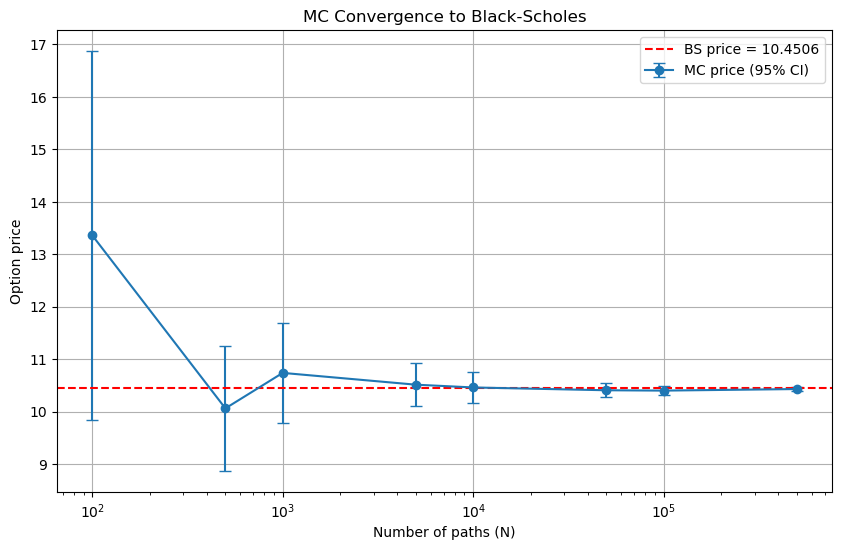

In [7]:
N_values = [100,500,1000,5000,10000,50000,100000,500000]
S0, K, r, sigma, T = 100,100,0.05,0.2,1.0
bs_price = Black_Scholes(S0,K,r,sigma,T,"call")
mc_price=[]
mc_error=[]

for N in N_values:
    price, se = european_mc(S0, K,r,sigma,T,n=252, n_paths=N, type="call")
    mc_price.append(price)
    mc_error.append(se)

plt.figure(figsize=(10,6))
plt.errorbar(N_values, mc_price, yerr=[1.96*e for e in mc_error], fmt='o-', capsize=4, label="MC price (95% CI)")
plt.axhline(bs_price, color='red', linestyle='--', label=f"BS price = {bs_price:.4f}")
plt.xscale('log')
plt.xlabel("Number of paths (N)")
plt.ylabel("Option price")
plt.title("MC Convergence to Black-Scholes")
plt.legend()
plt.grid(True)
plt.show()

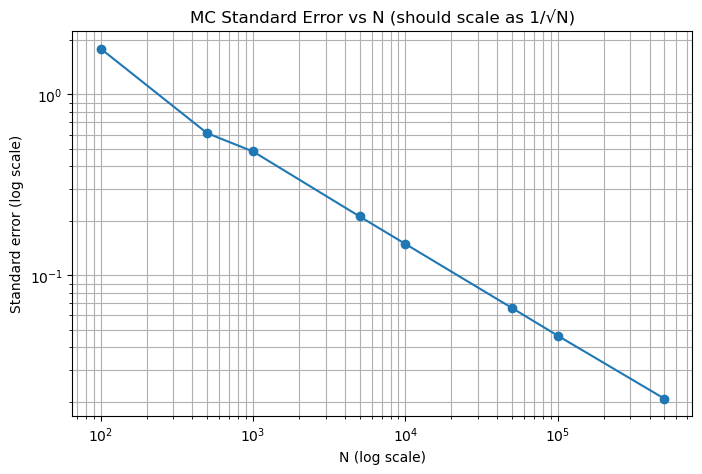

In [8]:
plt.figure(figsize=(8,5))
plt.loglog(N_values, mc_error, 'o-')
plt.xlabel("N (log scale)")
plt.ylabel("Standard error (log scale)")
plt.title("MC Standard Error vs N (should scale as 1/√N)")
plt.grid(True, which="both")
plt.show()

In [11]:
def european_mc_antithetic(S0, K, r, sigma, T, n, n_paths, type="call"):
    t, S = simulate_GBM_antithetic(S0, r, sigma, T, n, n_paths)
    S_T = S[:,-1]
    half = n_paths//2

    if type == "call":
        payoff = np.maximum(S_T-K, 0)
    else:
        payoff = np.maximum(K-S_T, 0)

    discount = np.exp(-r*T)*payoff
    pair_avg = 0.5*(discount[:half]+discount[half:])

    price = pair_avg.mean()
    std_err = pair_avg.std(ddof=1)/np.sqrt(half)
    return price, std_err

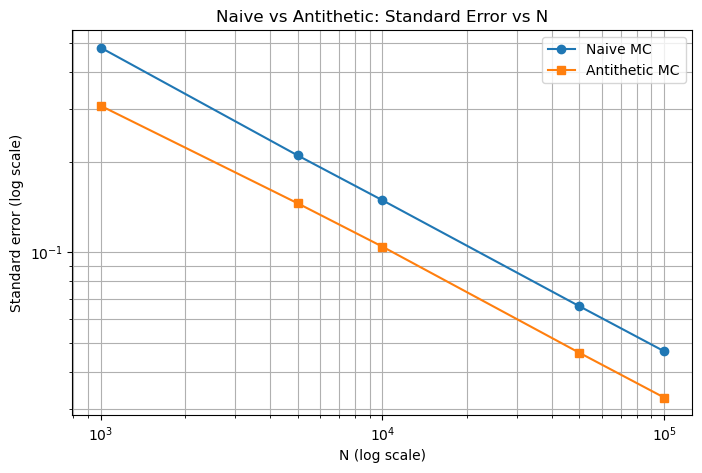

In [12]:
N_values = [1000, 5000, 10000, 50000, 100000]
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1.0

naive_errors = []
antithetic_errors = []

for N in N_values:
    _, se_naive = european_mc(S0, K, r, sigma, T, n=252, n_paths=N, type="call")
    _, se_anti = european_mc_antithetic(S0, K, r, sigma, T, n=252, n_paths=N, type="call")
    naive_errors.append(se_naive)
    antithetic_errors.append(se_anti)

plt.figure(figsize=(8,5))
plt.loglog(N_values, naive_errors, 'o-', label="Naive MC")
plt.loglog(N_values, antithetic_errors, 's-', label="Antithetic MC")
plt.xlabel("N (log scale)")
plt.ylabel("Standard error (log scale)")
plt.title("Naive vs Antithetic: Standard Error vs N")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [13]:
N = 10000
_, se_naive = european_mc(S0, K, r, sigma, T, n=252, n_paths=N, type="call")
_, se_anti = european_mc_antithetic(S0, K, r, sigma, T, n=252, n_paths=N, type="call")

var_reduction_ratio = (se_naive**2) / (se_anti**2)
print(f"Naive SE: {se_naive:.5f}")
print(f"Antithetic SE: {se_anti:.5f}")
print(f"Variance reduction ratio: {var_reduction_ratio:.2f}x")

Naive SE: 0.14462
Antithetic SE: 0.10406
Variance reduction ratio: 1.93x
